<a href="https://colab.research.google.com/github/mariasvynchuk/sales_analytics/blob/main/Sales_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [3]:
from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/data

countries = pd.read_csv("countries.csv")
events = pd.read_csv("events.csv")
products = pd.read_csv("products.csv")

Mounted at /content/drive
/content/drive/MyDrive/data


# Data Overview

In [4]:
print("countries:")
print(countries.head())
print()
print("events:")
print(events.head())
print()
print("products:")
print(products.head())

countries:
             name alpha-2 alpha-3   region       sub-region
0     Afghanistan      AF     AFG     Asia    Southern Asia
1   Åland Islands      AX     ALA   Europe  Northern Europe
2         Albania      AL     ALB   Europe  Southern Europe
3         Algeria      DZ     DZA   Africa  Northern Africa
4  American Samoa      AS     ASM  Oceania        Polynesia

events:
    Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70

In [5]:
print("countries:")
print(countries.info())
print()
print("events:")
print(events.info())
print()
print("products:")
print(products.info())

countries:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
None

events:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   fl

Таблиця **countries** містить дані про країни - 249 рядків і 5 колонок:
* name - назва країни
* Коди країн в колонках: alpha-2 і alpha-3
* region - регіон
* sub-region - суб-регіон

Таблиця **events** містить дані про замовлення і складається з 1330 рядків і десяти колонок:
* Order ID - ідентифікатор замовлення (int 64)
* Order Date - дата замовлення (object)
* Ship Date - дата доставки (object)
* Order Priority - пріоритетність замовлення (L — низький, M — середній, H — високий, C — критичний) (object)
* Country Code - код країни (object)
* Product ID - айді замовленого продукту (int64)
* Sales Channel - канал продажу (online, offline) (object)
* Units Sold - кількість проданих одиниць (float64)
* Unit Price - ціна продажу за одну одиницю товару (float64)
* Unit Cost - собівартість виробництва або закупівлі однієї одиниці товару (float64)

Таблиця **products** містить дані про продукцію - 12 рядків і складається з двох колонок:
* id - айді продукту (int64)
* item_type - назва типу продукту (object)

Поля що обєднують таблицю events з countries: *Country Code* в events і *alpha-3* в countries.

Поля що обєднують таблицю events з products: *Product ID* в events і *id* в products.

# Data Cleaning

**Виявлення пропущених значень:**

In [6]:
print(countries.isna().sum())

name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64


В таблиці countries є по одному пропущеному значенню в колонках alpha-2, region і sub-region. Аби не втратити дані про якісь країни, ці значення варто заповнити "Unknown"

In [7]:
countries = countries.fillna("Unknown")

In [8]:
print(events.isna().sum()) #missed values in events
print()
print(events.isna().sum() / events.shape[0] * 100) #percentage of na

Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64

Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


В таблиці events є два упущені значення в колонці Units Sold, їх заповнено середнім значенням

In [9]:
events["Units Sold"] = events["Units Sold"].fillna(events["Units Sold"].median())

Частка пропусків в колонці Country Code є досить великою - більше 6%. Тому їх варто заповнити.

In [10]:
events = events.fillna("Unknown")

In [11]:
print(products.isna().sum()) #na values in products

id           0
item_type    0
dtype: int64


В таблиці products пропусків немає.

**Перевірка типів даних:**

In [12]:
print(countries.dtypes)

name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object


В таблиці countries типи даних визначено правильно

In [13]:
print(events.dtypes)

Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object


Неправильно тип даних визначено в колонках Order Date та Ship Date таблиці events. Їх треба перетворити в Datetime.

In [14]:
events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])

In [15]:
print(events.dtypes)

Order ID                   int64
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Order Priority            object
Country Code              object
Product ID                 int64
Sales Channel             object
Units Sold               float64
Unit Price               float64
Unit Cost                float64
dtype: object


In [16]:
print(products.dtypes)

id            int64
item_type    object
dtype: object


В таблиці countries типи даних визначено правильно

**Виявлення дублікатів:**

In [17]:
print("The ammount of duplicated rows in countries:", countries.duplicated().sum())
print("The ammount of duplicated rows in events:", events.duplicated().sum())
print("The ammount of duplicated rows in products:", products.duplicated().sum())

The ammount of duplicated rows in countries: 0
The ammount of duplicated rows in events: 0
The ammount of duplicated rows in products: 0


Дублікатів немає

**Виявлення аномалій:**

In [18]:
events.describe()

,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330,1330,1330.000000,1330.000000,1330.000000,1330.000000
mean,5.412048e+08,2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,5788.096241,4952.216541,264.893541,187.246812
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,2011-12-16 06:00:00,2012-01-03 00:00:00,3127.000000,2360.750000,81.730000,35.840000
50%,5.387164e+08,2013-10-17 00:00:00,2013-11-09 00:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,2015-08-28 18:00:00,2015-10-03 18:00:00,8681.000000,7458.750000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573882e+08,NaN,NaN,2820.728878,2903.012194,217.323460,176.158873


Аномалій не виявлено

# Data analysis and visualization

## Data preparation

Об'єднання таблиць. Колонки не потрібні для аналізу видалено: alpha-2, alpha-3, id. Уніфікація стилю найменування колонок і перейменування окремих колонок.

In [19]:
#data joining
df = pd.merge(events, products, how = "inner", left_on = "Product ID", right_on = "id")
df = pd.merge(df, countries, how="left", left_on = "Country Code", right_on = "alpha-3")

df = df.drop(columns = ["alpha-2","alpha-3","id"]) #removing excessive data
df.columns = df.columns.str.lower().str.replace(" ","_") #unifying colum naming style
df = df.rename(columns={'name': 'country'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1330 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1330 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
 10  item_type       1330 non-null   object        
 11  country         1248 non-null   object        
 12  region          1248 non-null   object        
 13  sub-region      1248 non-null   object        
dtypes: datetime64[ns](2), float64(3), int64(2), object(7)
me

In [20]:
df=df.fillna("Unknown")
df.isna().sum()

,0
order_id,0
order_date,0
ship_date,0
order_priority,0
country_code,0
product_id,0
sales_channel,0
units_sold,0
unit_price,0
unit_cost,0


## Key Total Metrics

**Обчислення ключових загальних метрик**

Також додано колонку order_revenue, order_profit, order_cost які містять обчислені дані про дохід, прибуток і витрати.

In [21]:
#total orders
total_orders = df["order_id"].count()
print(f"Загальна кількість замовлень: {total_orders}")

#total profit
df["order_revenue"] = df["units_sold"]*df["unit_price"] #order revenue column
df["order_cost"] =df["units_sold"]*df["unit_cost"] #order cost column
df["order_profit"] = df["order_revenue"] - df["order_cost"] #order profit column
total_profit = df["order_profit"].sum()
print(f"Загальний прибуток: {total_profit}")

#total countries
total_countries = df["country"].nunique()
print(f"Загальна кількість охоплепих країн: {total_countries}")

#total units sold
total_units_sold = df["units_sold"].sum()
print(f"Загальна кількість проданих товарів: {total_units_sold}")

#item types ammount
total_item_types = df["item_type"].nunique()
print(f"Кількість різних типів проданих товарів: {total_item_types}")

Загальна кількість замовлень: 1330
Загальний прибуток: 501842633.11999995
Загальна кількість охоплепих країн: 46
Загальна кількість проданих товарів: 6586448.0
Кількість різних типів проданих товарів: 12


## Аналіз продажів

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import EngFormatter #numbers formatting

In [23]:
df.describe()

,order_id,order_date,ship_date,product_id,units_sold,unit_price,unit_cost,order_revenue,order_cost,order_profit
count,1.330000e+03,1330,1330,1330.000000,1330.000000,1330.000000,1330.000000,1.330000e+03,1.330000e+03,1.330000e+03
mean,5.412048e+08,2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,5788.096241,4952.216541,264.893541,187.246812,1.281675e+06,9.043502e+05,3.773253e+05
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000,5.038200e+02,3.736800e+02,1.301400e+02
25%,3.190004e+08,2011-12-16 06:00:00,2012-01-03 00:00:00,3127.000000,2360.750000,81.730000,35.840000,2.665647e+05,1.577943e+05,8.498177e+04
50%,5.387164e+08,2013-10-17 00:00:00,2013-11-09 00:00:00,5988.000000,4962.000000,154.060000,97.440000,7.613049e+05,4.332233e+05,2.748680e+05
75%,7.544628e+08,2015-08-28 18:00:00,2015-10-03 18:00:00,8681.000000,7458.750000,437.200000,263.330000,1.743428e+06,1.108873e+06,5.476582e+05
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000,6.672676e+06,5.248025e+06,1.700449e+06
std,2.573882e+08,NaN,NaN,2820.728878,2903.012194,217.323460,176.158873,1.443148e+06,1.135050e+06,3.689180e+05


Візуалізація розподілів кількості проданих товарів та доходів від замовлення

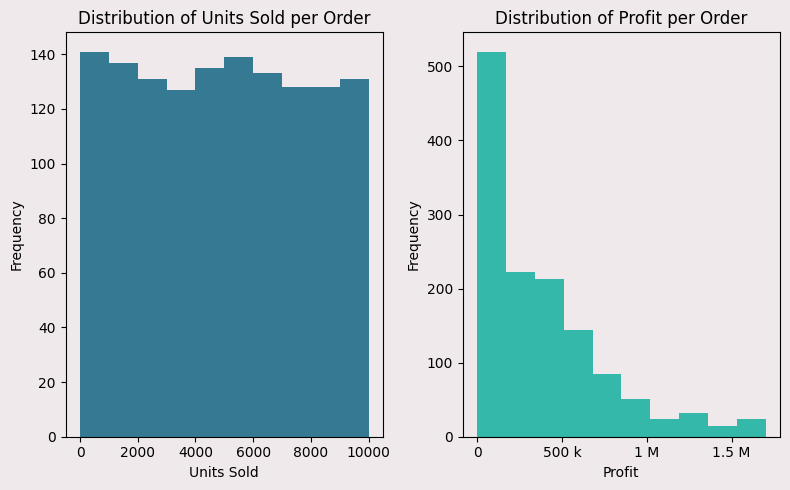

In [37]:
fig, axes = plt.subplots(1,2, figsize = (8,5), facecolor = "#efe9eb")

#distribution of units sold
axes[0].hist(df["units_sold"], color = "#367993")
axes[0].set_title("Distribution of Units Sold per Order")
axes[0].set_xlabel("Units Sold")
axes[0].set_ylabel("Frequency")
axes[0].patch.set_facecolor("#efe9eb")

#distribution of profit
axes[1].hist(df["order_profit"], color = "#34b8aa")
axes[1].set_title("Distribution of Profit per Order")
axes[1].set_xlabel("Profit")
axes[1].set_ylabel("Frequency")
axes[1].xaxis.set_major_formatter(EngFormatter(unit=''))
axes[1].patch.set_facecolor("#efe9eb")

plt.tight_layout()
plt.show()

Кількість проданих товарів розподілена нормально з середнім значенням приблизно 5000 проданих одиниць за замовлення.
Більшість замовлень приносять дохід до 500 тисяч.

**Аналіз продажів в розрізі категорій товарів**

In [25]:
#total orders per category
print("Кількість замовлень за категоріями")
orders_per_category = df["item_type"].value_counts()
print(orders_per_category)
print()
#Total profit per category
print("Дохід за категоріями")
profit_per_category = df.groupby('item_type')['order_profit'].sum().sort_values(ascending=False)
print(profit_per_category)
print()
#Total units sold per category
print("Кількість проданих товарів за категоріями")
units_sold_per_category = df.groupby('item_type')['units_sold'].sum().sort_values(ascending=False)
print(units_sold_per_category)

Кількість замовлень за категоріями
item_type
Office Supplies    123
Beverages          121
Personal Care      115
Cosmetics          114
Vegetables         114
Baby Food          112
Fruits             112
Meat               111
Clothes            105
Cereal             103
Snacks             103
Household           97
Name: count, dtype: int64

Дохід за категоріями
item_type
Cosmetics          92723306.17
Office Supplies    77977176.25
Household          72962466.77
Baby Food          53940997.16
Clothes            43431314.40
Cereal             41255034.15
Vegetables         36776002.72
Meat               30621562.40
Snacks             27027422.40
Personal Care      14099758.40
Beverages           9601662.78
Fruits              1425929.52
Name: order_profit, dtype: float64

Кількість проданих товарів за категоріями
item_type
Office Supplies    617641.0
Beverages          613133.0
Fruits             591672.0
Clothes            591385.0
Vegetables         582544.0
Baby Food          56

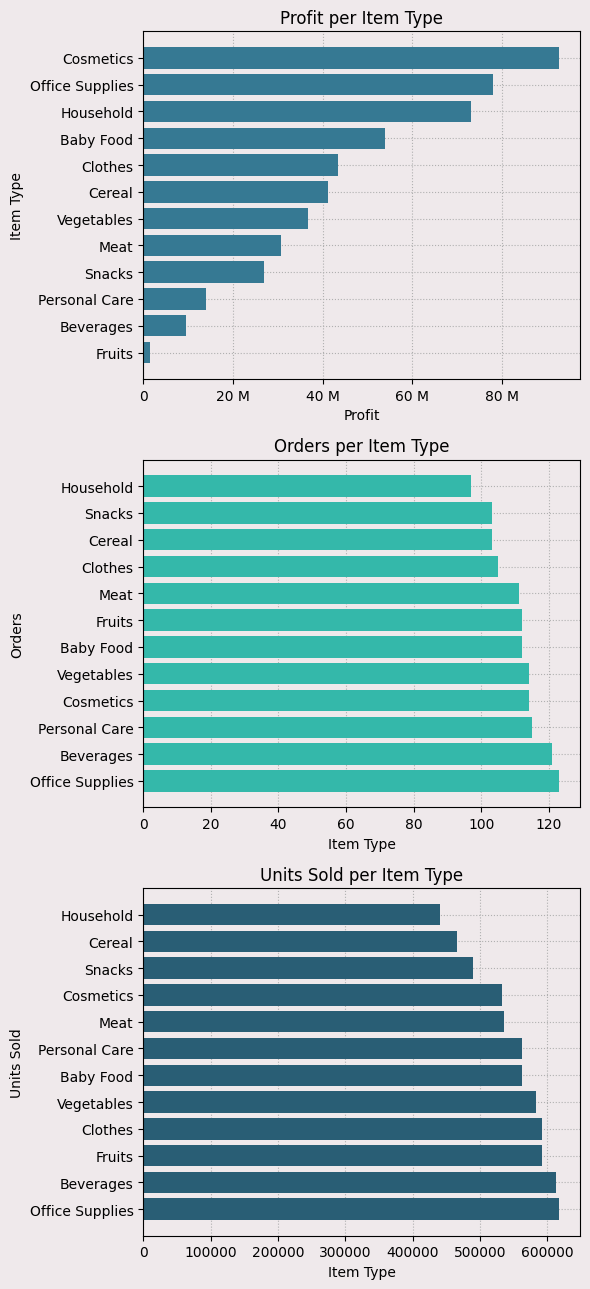

In [34]:
fig, axes = plt.subplots(3,1, figsize=(6,13), facecolor = "#efe9eb")

#Total profit per item type
axes[0].barh(profit_per_category.index,
             profit_per_category.values,
             color = "#367993")
axes[0].set_xlabel('Profit')
axes[0].set_ylabel('Item Type')
axes[0].set_title('Profit per Item Type')
axes[0].invert_yaxis() #descending order
axes[0].xaxis.set_major_formatter(EngFormatter(unit=''))
axes[0].grid(True, linestyle=":")
axes[0].set_axisbelow(True)
axes[0].patch.set_facecolor('#efe9eb')

#Total orders per item type
axes[1].barh(orders_per_category.index,
             orders_per_category.values,
             color = "#34b8aa")
axes[1].set_title("Orders per Item Type")
axes[1].set_xlabel("Item Type")
axes[1].set_ylabel("Orders")
axes[1].grid(True, linestyle=":")
axes[1].set_axisbelow(True)
axes[1].patch.set_facecolor('#efe9eb')

#total units sold per item type
axes[2].barh(units_sold_per_category.index,
             units_sold_per_category.values,
             color = "#295e75")
axes[2].set_title("Units Sold per Item Type")
axes[2].set_xlabel("Item Type")
axes[2].set_ylabel("Units Sold")
axes[2].grid(True, linestyle=":")
axes[2].set_axisbelow(True)
axes[2].patch.set_facecolor('#efe9eb')

plt.tight_layout()
plt.show()

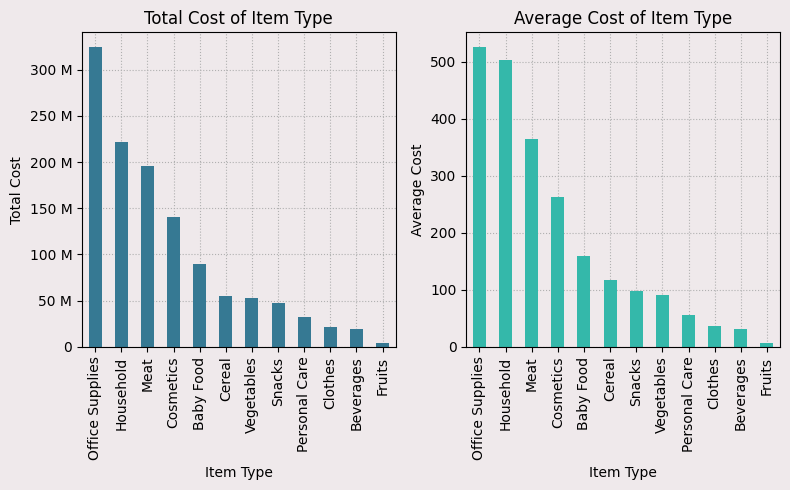

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5), facecolor = "#efe9eb")

#Total cost per item type
total_cost_per_category = df.groupby('item_type')['order_cost'].sum().sort_values(ascending=False)
total_cost_per_category.plot(kind = "bar", ax = axes[0], color = "#367993")
axes[0].set_xlabel("Item Type")
axes[0].set_ylabel("Total Cost")
axes[0].set_title("Total Cost of Item Type")
axes[0].yaxis.set_major_formatter(EngFormatter(unit=''))
axes[0].grid(True, linestyle = ":")
axes[0].set_axisbelow(True)
axes[0].patch.set_facecolor('#efe9eb')

#mean cost per item type
mean_cost_per_category = df.groupby('item_type')['unit_cost'].mean().sort_values(ascending=False)
mean_cost_per_category.plot(kind = "bar", ax = axes[1], color = "#34b8aa")
axes[1].set_title("Average Cost of Item Type")
axes[1].set_xlabel("Item Type")
axes[1].set_ylabel("Average Cost")
axes[1].grid(True, linestyle = ":")
axes[1].set_axisbelow(True)
axes[1].patch.set_facecolor('#efe9eb')

plt.tight_layout()
plt.show()

- **Найприбутковіша категорія товарів** - косметика *(Cosmetics)*. Вона є лідером за загальним прибутком *(приблизно 92.7 млн)*, попри те, що не є лідером за кількістю замовлень. Це вказує на високу маржинальність цього виду товару.

- Офісні товари *(Office Supplies)* мають **найвищу кількість замовлень** (123) та **найбільшу кількість проданих одиниць** (приблизно 617 тис.) , проте за прибутком вони поступаються косметиці. Також ця категорія має **найвищу собівартість**.

- Фрукти *(Fruits)* приносять **найменший прибуток**  (приблизно 1.4 млн), хоча за обсягами проданих одиниць (приблизно 591 тис.) вони знаходяться на рівні з одягом. Це свідчить про низьку націнку або низьку вартість одиниці товару.

Отже, компанія має чіткий сегмент high-margin продуктів, які варто пріоритизувати у маркетингу та плануванні запасів. Категорії Cosmetics, Office Supplies, Household генерують найбільший загальний прибуток.

Низькомаржинальні категорії, на кшталт Fruits та Beverages, доцільно або оптимізувати за собівартістю, або використовувати як для залучення клієнтів.

**Аналіз продажів в розрізі географії**

In [ ]:
df.groupby("country").agg(
    orders=("order_id", "count"),
    profit=("order_profit", "sum"),
    avg_order_profit=("order_profit", "mean")
).sort_values("profit", ascending=False)


,orders,profit,avg_order_profit
country,,,
Unknown,82,27725423.94,338114.926098
Andorra,40,15410036.63,385250.915750
Ukraine,33,14804925.74,448634.113333
Malta,32,14610127.88,456566.496250
San Marino,40,13792992.81,344824.820250
Hungary,25,13786231.03,551449.241200
Macedonia,32,13684099.95,427628.123437
Czech Republic,31,13635593.78,439857.863871
Russia,32,13267682.64,414615.082500


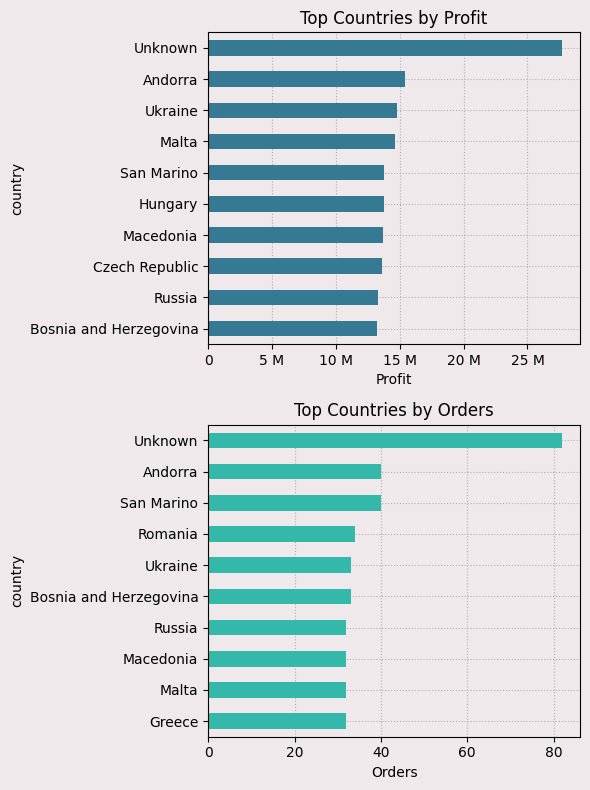

In [39]:
fig, axes = plt.subplots(2,1, figsize = (6,8), facecolor = "#efe9eb")

#top 10 countries profit visualization
profit_per_country = df.groupby("country")["order_profit"].sum().sort_values(ascending=False) #total profit per country
top_countries_profit = profit_per_country.head(10)
top_countries_profit.plot(kind="barh", ax = axes[0], color = "#367993")
axes[0].invert_yaxis()
axes[0].set_title("Top Countries by Profit")
axes[0].set_xlabel("Profit")
axes[0].xaxis.set_major_formatter(EngFormatter(unit=''))
axes[0].grid(True, linestyle = ":")
axes[0].set_axisbelow(True)
axes[0].patch.set_facecolor("#efe9eb")

#top 10 countries profit visualization
sales_per_country = df.groupby("country")["order_id"].count().sort_values(ascending=False)
top_countries_sales = sales_per_country.head(10)
top_countries_sales.plot(kind="barh", ax = axes[1], color = "#34b8aa")
axes[1].invert_yaxis()
axes[1].set_title("Top Countries by Orders")
axes[1].set_xlabel("Orders")
axes[1].xaxis.set_major_formatter(EngFormatter(unit=''))
axes[1].grid(True, linestyle = ":")
axes[1].set_axisbelow(True)
axes[1].patch.set_facecolor("#efe9eb")

plt.tight_layout()
plt.show()

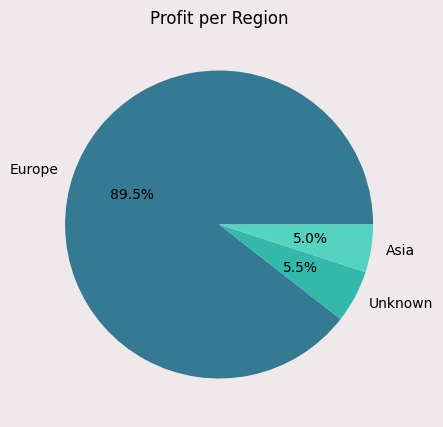

In [40]:
#total profit per region
profit_by_region = df.groupby("region")["order_profit"].sum().sort_values(ascending=False)

colors = ["#367993","#34b8aa","#54d3c0"]

fig, ax = plt.subplots(figsize=(5, 5), facecolor="#efe9eb")
profit_by_region.plot.pie(
    ax=ax,
    labels=profit_by_region.index,
    autopct='%1.1f%%',
    colors=colors)
ax.set_title("Profit per Region")
ax.set_ylabel("")
plt.show()

Країни, що приносять навищий дохід це Андорра (~15 млн.), Україна та Мальта (по ~14 млн). Хоча за кількістю замовлень в лідерах є також Румунія та Сан-Марино.
Доцільно інвестувати в локальні маркетингові активності та покращувати логістику саме в top-markets.

Нідерланди, Грузія та Монако це країни з найнижчим прибутком. Вони мають найнижчий середній дохід і не найменшу кількість замовлень. Вони можуть бути кандидатами на перегляд стратегії присутності.

Регіон Європа генерує переважну більшість прибутку — 89.5%. Азія займає лише 5%. Це свідчить про сильну концентрацію бізнесу на одному ринку.

**Аналіз продажів в розрізі каналів продажу**

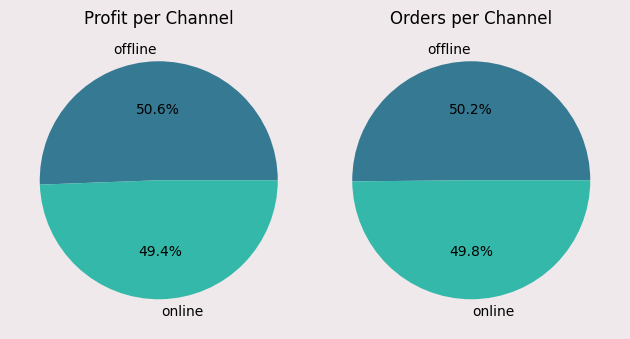

In [41]:
df["sales_channel"] = df["sales_channel"].str.lower() #to unify channel names
fig, axes = plt.subplots(1,2, facecolor = "#efe9eb")

colors = ["#367993","#34b8aa"]

#total profit per sales channel
profit_by_channel = df.groupby("sales_channel")["order_profit"].sum()
profit_by_channel.plot.pie(labels = profit_by_channel.index,
                           autopct='%1.1f%%',
                           ax = axes[0],
                           colors=colors)
axes[0].set_title("Profit per Channel")
axes[0].set_ylabel("")
axes[0].patch.set_facecolor("#efe9eb")

#total orders per sales channel
sales_by_channel = df.groupby("sales_channel")["order_id"].count()
sales_by_channel.plot.pie(labels = sales_by_channel.index,
                          autopct='%1.1f%%',
                          ax = axes[1],
                          colors=colors)
axes[1].set_title("Orders per Channel")
axes[1].set_ylabel("")
axes[1].patch.set_facecolor("#efe9eb")

plt.tight_layout()
plt.show()

Бізнес демонструє здоровий баланс між Online та Offline продажами (майже 50 на 50).

## Аналіз термінів між замовленням та його відвантаженням

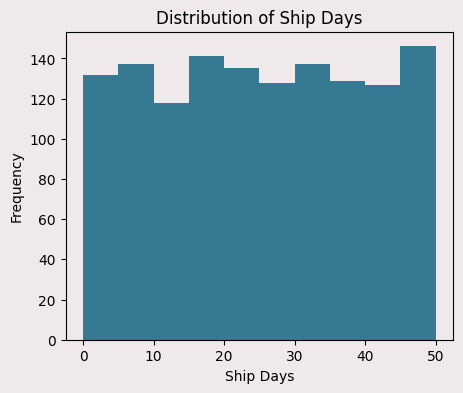

In [42]:
df["ship_days"] = (df["ship_date"] - df["order_date"]).dt.days #add a ship_days column with ship term in days

fig, ax = plt.subplots(figsize = (5,4), facecolor = "#efe9eb")

ax.hist(df["ship_days"], color = "#367993")
ax.set_title("Distribution of Ship Days")
ax.set_xlabel("Ship Days")
ax.set_ylabel("Frequency")
ax.patch.set_facecolor("#efe9eb")

plt.show()


Розподіл днів на відвантаження є досить рівномірним у діапазоні від 0 до 50 днів.

In [43]:
ship_days_per_category = df.groupby("item_type")["ship_days"].mean().sort_values(ascending=False)
ship_days_per_country = df.groupby("country")["ship_days"].mean().sort_values(ascending=False)
ship_days_per_region = df.groupby("region")["ship_days"].mean()

from IPython.display import display
display(
    ship_days_per_category.to_frame("Avg ship days").style.set_caption("By Item Type"),
    ship_days_per_country.to_frame("Avg ship days").style.set_caption("By Country"),
    ship_days_per_region.to_frame("Avg ship days").style.set_caption("By Region"))


,Avg ship days
item_type,
Cereal,27.184466
Office Supplies,26.707317
Baby Food,26.339286
Cosmetics,25.912281
Meat,25.846847
Snacks,25.543689
Fruits,24.419643
Beverages,24.123967
Household,23.938144


,Avg ship days
country,
Hungary,32.640000
Georgia,29.695652
Austria,28.500000
Slovakia,28.466667
Luxembourg,27.750000
Lithuania,27.560000
Poland,27.464286
Russia,27.375000
Monaco,26.846154


,Avg ship days
region,
Asia,26.085366
Europe,24.777873
Unknown,23.439024


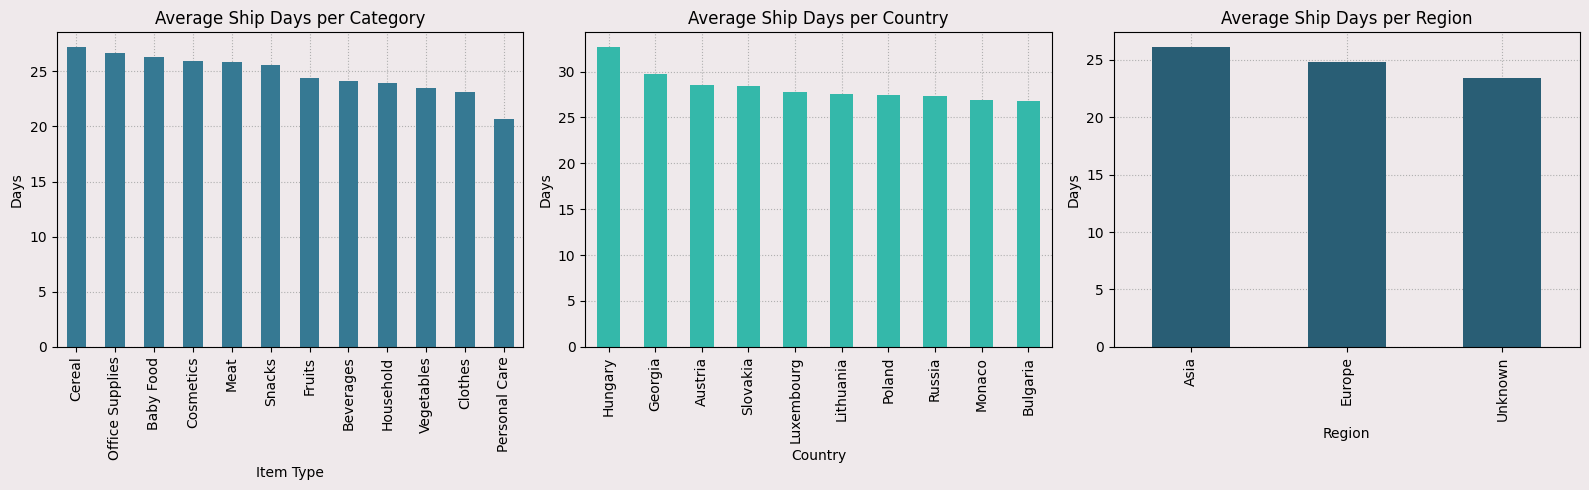

In [45]:
fig,axes = plt.subplots(1,3, figsize = (16,5), facecolor = "#efe9eb")

#average ship days per item type
ship_days_per_category.plot(kind="bar",
                            ax=axes[0],
                            color = "#367993")
axes[0].set_title("Average Ship Days per Category")
axes[0].set_ylabel("Days")
axes[0].set_xlabel("Item Type")
axes[0].patch.set_facecolor("#efe9eb")
axes[0].grid(True, linestyle = ":")
axes[0].set_axisbelow(True)

#average ship days per country
top_countries_shipping = ship_days_per_country.head(10)
top_countries_shipping.plot(kind="bar",
                            ax=axes[1],
                            color = "#34b8aa")
axes[1].set_title("Average Ship Days per Country")
axes[1].set_ylabel("Days")
axes[1].set_xlabel("Country")
axes[1].patch.set_facecolor("#efe9eb")
axes[1].grid(True, linestyle = ":")
axes[1].set_axisbelow(True)

#average ship days per region
ship_days_per_region = df.groupby("region")["ship_days"].mean()
ship_days_per_region.plot(kind="bar",
                          ax=axes[2],
                          color = "#295e75")
axes[2].set_title("Average Ship Days per Region")
axes[2].set_ylabel("Days")
axes[2].set_xlabel("Region")
axes[2].patch.set_facecolor("#efe9eb")
axes[2].grid(True, linestyle = ":")
axes[2].set_axisbelow(True)

plt.tight_layout()
plt.show()


Найдовший середній термін відвантаження мають пластівці (Cereal), офісні товари(Office Supplies) та дитяче харчування (Baby Food) — понад 26 днів.
Найшвидше відвантажуються товари категорії Personal Care (Особиста гігієна) — приблизно 20–21 день.
Категорії з довшим часом відвантаженням є потенційними проблемами у логістиці й потребують пріоритетної оптимізації, особливо якщо вони також приносять значний дохід.

Різниця у часі відвантаження між країнами — понад 14 днів, що є значним розривом. Угорщина має найвищий середній показник затримки — понад 30 днів. Грузія та Австрія також демонструють тривалі терміни відвантаження (28–30 днів). Країни з високим доходом і довгим часом відвантаження це ключові кандидати для інвестицій у локальну логістику або оптимізацію постачання.

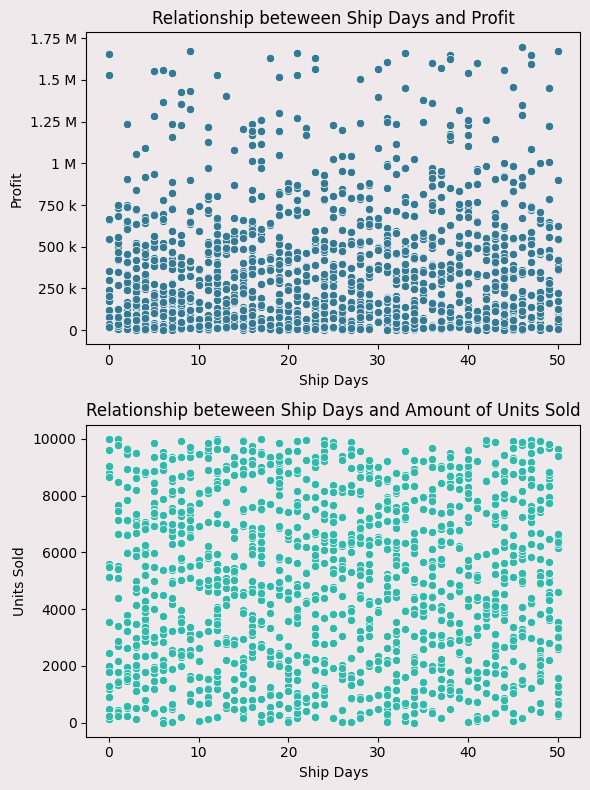

In [47]:
fig, axes = plt.subplots(2,1, figsize=(6,8), facecolor = "#efe9eb")

#profit and ship days relationships
sns.scatterplot(data=df,x="ship_days",
                y="order_profit",
                ax=axes[0],
                color = "#367993")
axes[0].set_title("Relationship beteween Ship Days and Profit")
axes[0].set_xlabel("Ship Days")
axes[0].set_ylabel("Profit")
axes[0].yaxis.set_major_formatter(EngFormatter(unit=''))
axes[0].patch.set_facecolor("#efe9eb")

#amount of units sold and ship days relationships
sns.scatterplot(data=df,
                x="ship_days",
                y="units_sold",
                ax=axes[1],
                color = "#34b8aa")
axes[1].set_title("Relationship beteween Ship Days and Amount of Units Sold")
axes[1].set_xlabel("Ship Days")
axes[1].set_ylabel("Units Sold")
axes[1].patch.set_facecolor("#efe9eb")

plt.tight_layout()
plt.show()

Графіки розсіювання показують, що немає прямої залежності між тривалістю доставки та прибутком або кількістю проданих товарів

## Динаміка продажів

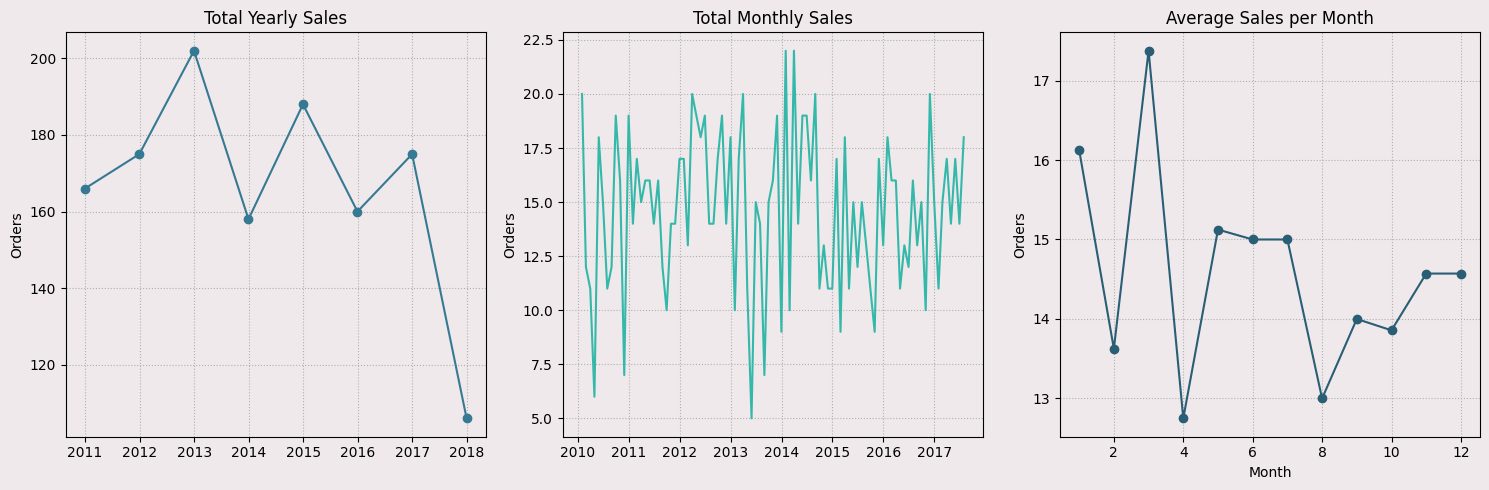

In [49]:
#ORDERS AMOUNT DYNAMICS
fig, axes = plt.subplots(1,3, figsize = (15,5), facecolor = "#efe9eb")

yearly_sales = df.groupby(pd.Grouper(key="order_date", freq="YE"))["order_id"].count() #count of orders per year
axes[0].plot(yearly_sales, color = "#367993", marker = "o")
axes[0].set_title("Total Yearly Sales")
axes[0].set_ylabel("Orders")
axes[0].patch.set_facecolor("#efe9eb")
axes[0].grid(True, linestyle = ":", zorder = 0)

monthly_sales = df.groupby(pd.Grouper(key="order_date", freq="ME"))["order_id"].count() #count of orders per month
axes[1].plot(monthly_sales, color = "#34b8aa")
axes[1].set_title("Total Monthly Sales")
axes[1].set_ylabel("Orders")
axes[1].patch.set_facecolor("#efe9eb")
axes[1].grid(True, linestyle = ":", zorder = 0)

#seasonality
monthly_sales = pd.DataFrame({"order_date" : list(monthly_sales.index), "orders" : list(monthly_sales.values)}) #df monthly sales for further grouping
sales_seasonality = monthly_sales.groupby(monthly_sales["order_date"].dt.month)["orders"].mean() #mean orders amount per month
axes[2].plot(sales_seasonality, color = "#295e75", marker = "o")
axes[2].set_title("Average Sales per Month")
axes[2].set_ylabel("Orders")
axes[2].set_xlabel("Month")
axes[2].patch.set_facecolor("#efe9eb")
axes[2].grid(True, linestyle = ":", zorder = 0)

plt.tight_layout()
plt.show()

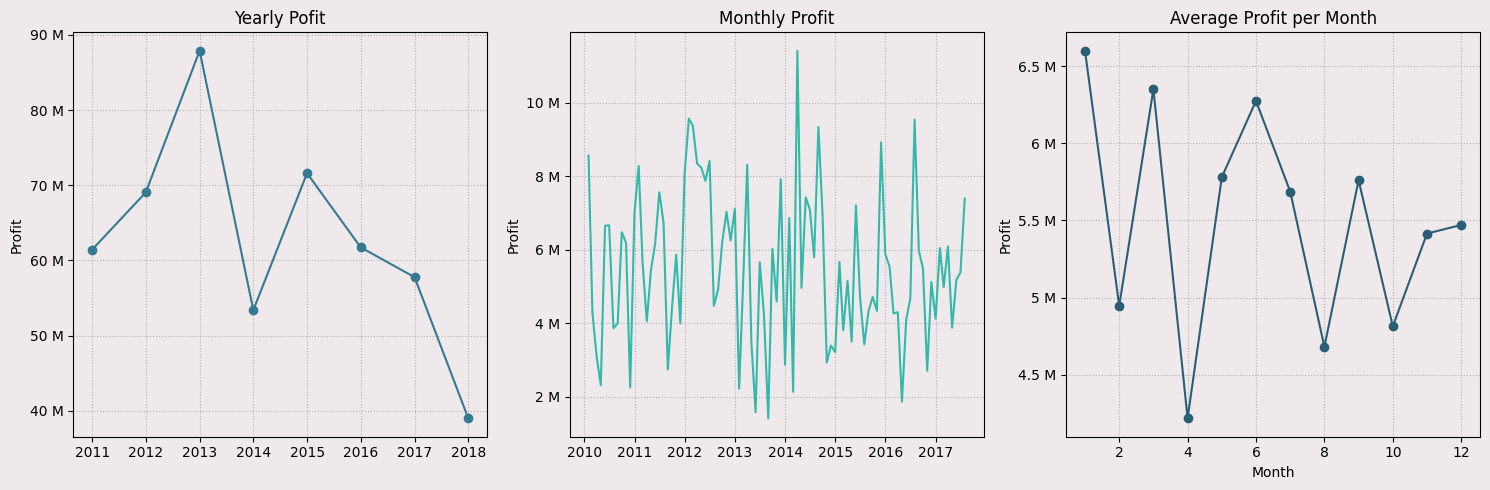

In [50]:
#PROFIT DYNAMICS
fig, axes = plt.subplots(1,3, figsize = (15,5), facecolor = "#efe9eb")

yearly_profit = df.groupby(pd.Grouper(key="order_date", freq="YE"))["order_profit"].sum()
axes[0].plot(yearly_profit, color = "#367993", marker = "o")
axes[0].set_title("Yearly Pofit")
axes[0].set_ylabel("Profit")
axes[0].yaxis.set_major_formatter(EngFormatter(unit=''))
axes[0].patch.set_facecolor("#efe9eb")
axes[0].grid(True, linestyle = ":", zorder = 0)

monthly_profit = df.groupby(pd.Grouper(key="order_date", freq="ME"))["order_profit"].sum()
axes[1].plot(monthly_profit, color = "#34b8aa")
axes[1].set_title("Monthly Profit")
axes[1].set_ylabel("Profit")
axes[1].yaxis.set_major_formatter(EngFormatter(unit=''))
axes[1].patch.set_facecolor("#efe9eb")
axes[1].grid(True, linestyle = ":", zorder = 0)

#seasonality
monthly_profit = pd.DataFrame({"order_date" : list(monthly_profit.index),
                               "profit" : list(monthly_profit.values)}) #df monthly profit for further grouping
profit_seasonality = monthly_profit.groupby(monthly_profit["order_date"].dt.month)["profit"].mean() #mean orders amount per month
axes[2].plot(profit_seasonality, color = "#295e75", marker = "o")
axes[2].set_title("Average Profit per Month")
axes[2].set_ylabel("Profit")
axes[2].set_xlabel("Month")
axes[2].yaxis.set_major_formatter(EngFormatter(unit=''))
axes[2].patch.set_facecolor("#efe9eb")
axes[2].grid(True, linestyle = ":", zorder = 0)

plt.tight_layout()
plt.show()

Найвищий рівень річного прибутку був зафіксований у 2013 році (майже 90 млн).  У 2014 році відбувся різкий спад прибутку до ~50 млн, після чого у 2015 році спостерігалося часткове відновлення. Починаючи з 2015 року, прибуток стабільно падає. Це вказує на необхідність перегляду бізнес-стратегії.
Найвища прибутковість спостерігається у січні та червні. Це може бути пов’язано з післяноворічними закупівлями та початком літнього сезону.

**Сезонність продажів різних типів товарів за днями тижня**

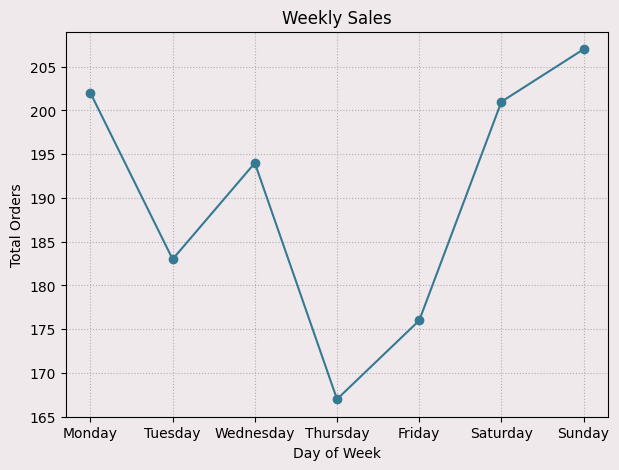

In [51]:
#overall sales weekly seasonality
weekly_sales = df.groupby(df["order_date"].dt.day_name())["order_id"].count()

plot_df = weekly_sales.reset_index(name='order_count')
#sort by weeekdays
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']
plot_df['order_date'] = pd.Categorical(plot_df['order_date'],
                                       categories=day_order,
                                       ordered=True)
plot_df = plot_df.sort_values('order_date')

fig, ax = plt.subplots(figsize = (7,5), facecolor = "#efe9eb")
ax.plot(plot_df["order_date"],
        plot_df["order_count"],
        marker="o",
        color = "#367993")
ax.set_title("Weekly Sales")
ax.set_ylabel("Total Orders")
ax.set_xlabel("Day of Week")
ax.patch.set_facecolor("#efe9eb")
ax.grid(True, linestyle = ":", zorder = 0)
plt.show()

Загальна кількість замовлень розподіляється нерівномірно, з чітким акцентом на вихідні. Найбільша кількість замовлень припадає на неділю (понад 205 замовлень) та понеділок/суботу. У четвер спостерігається значне падіння кількості замовлень (мінімум — близько 167).

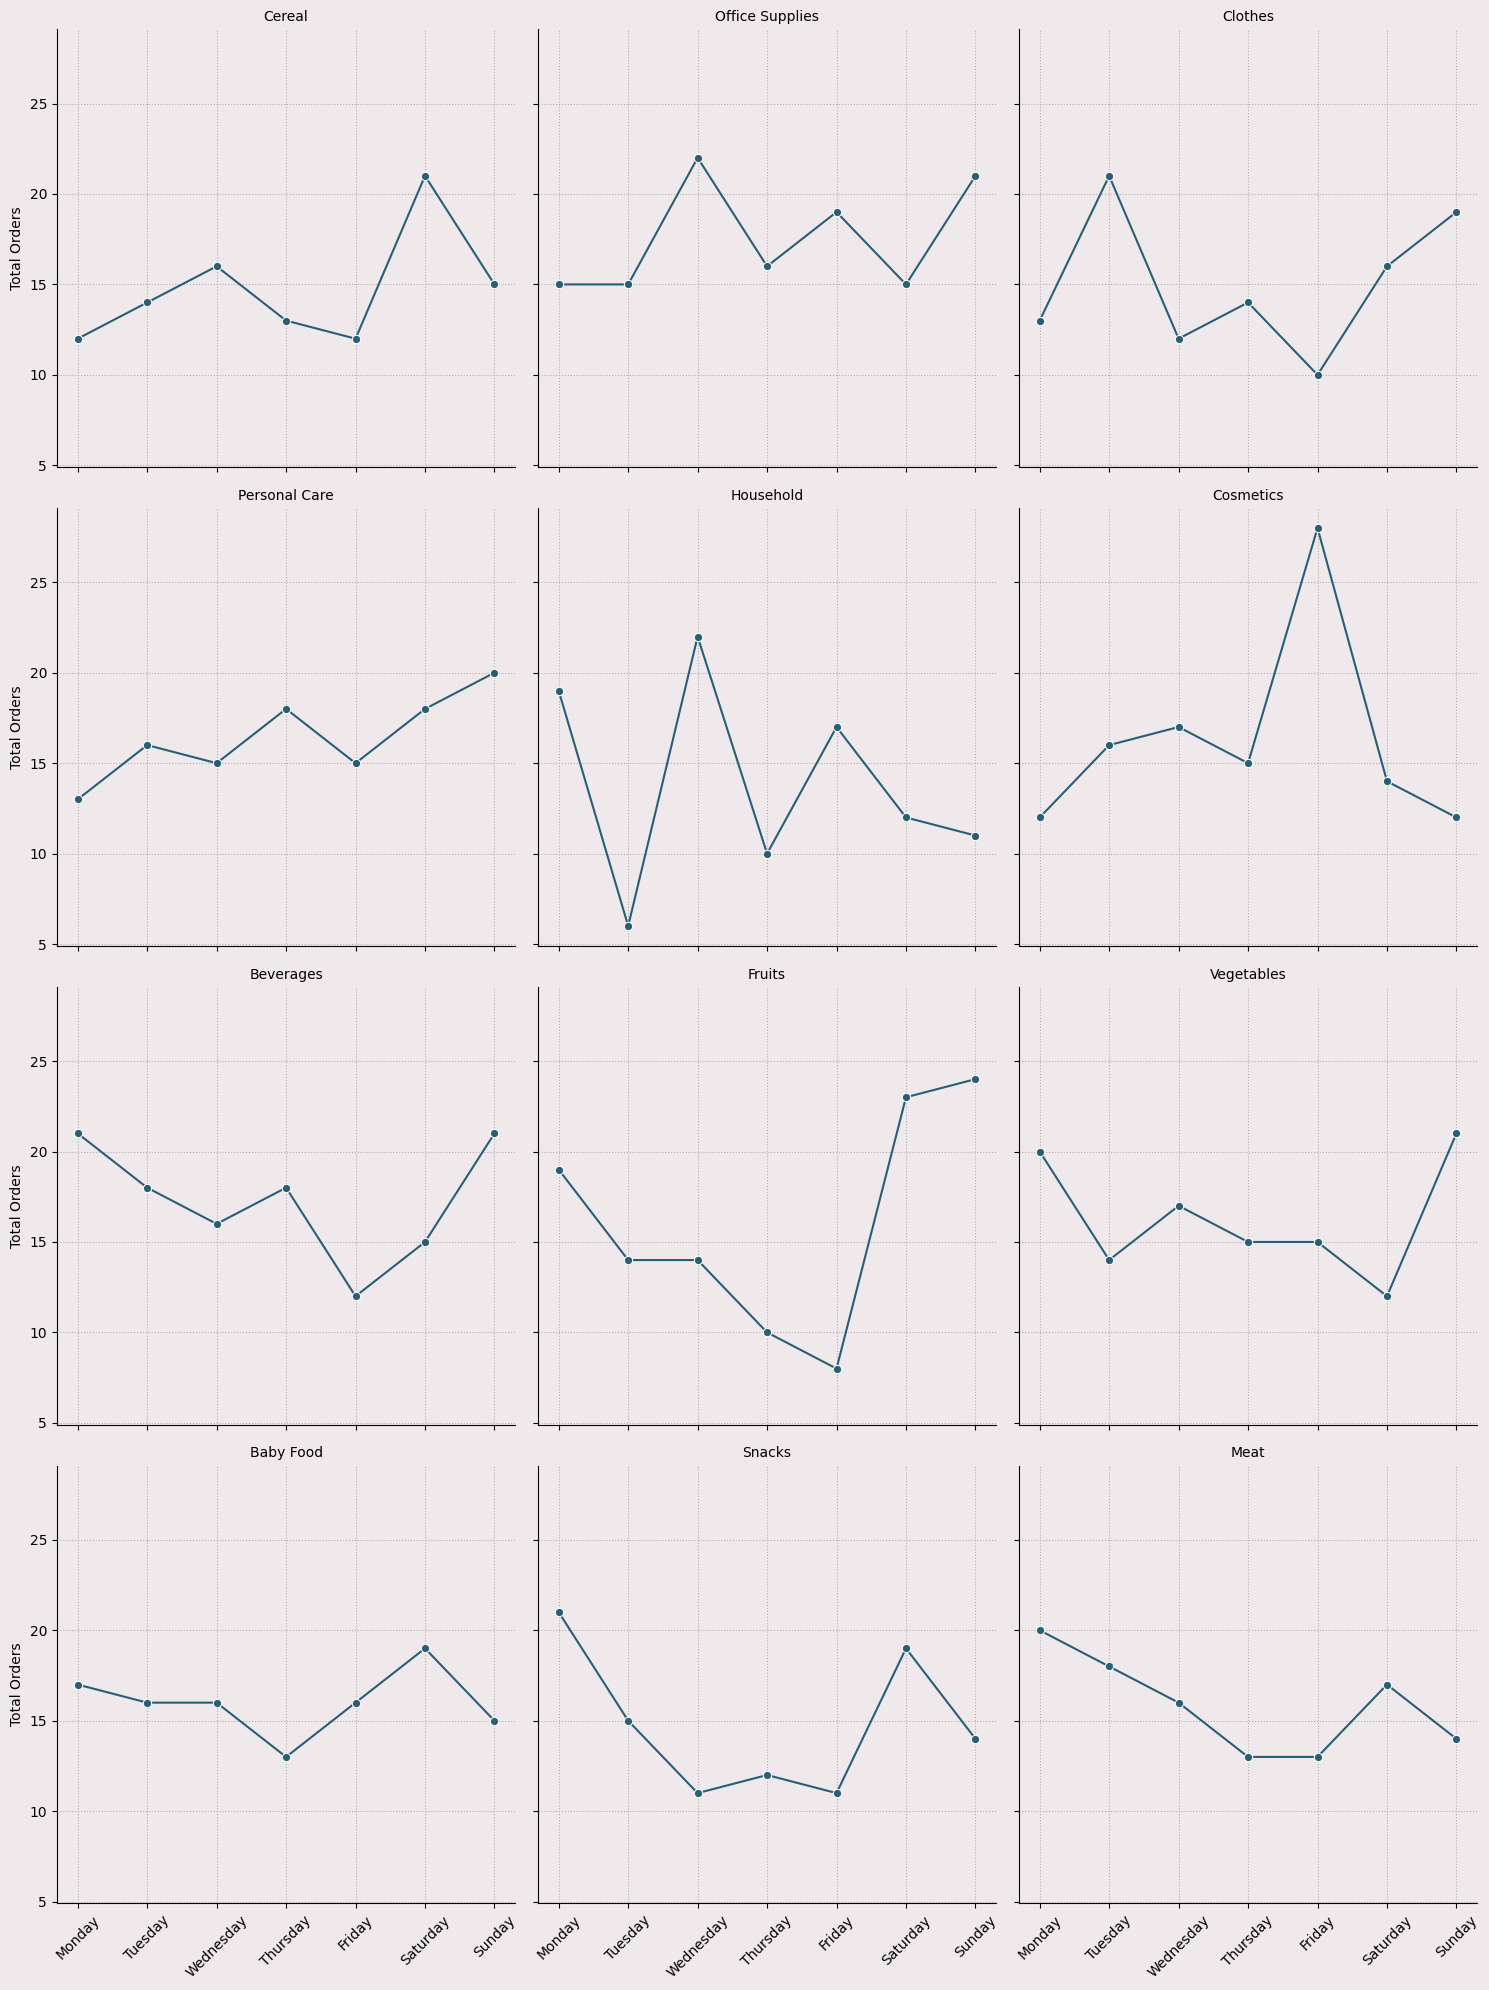

In [52]:
item_types_sales = df.groupby(["item_type", df["order_date"].dt.day_name()])["order_id"].count()

plot_df = item_types_sales.reset_index(name='order_count')
#sort by weekdaysdays
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']
plot_df['order_date'] = pd.Categorical(plot_df['order_date'],
                                       categories=day_order,
                                       ordered=True)
plot_df = plot_df.sort_values('order_date')

#plotting weekly dynamics
g = sns.relplot(data=plot_df,
                x='order_date',
                y='order_count',
                col='item_type',
                kind='line',
                marker='o',
                col_wrap=3,
                color = "#295e75")
g.figure.set_facecolor("#efe9eb")
g.set_axis_labels("", "Total Orders")
g.set_titles("{col_name}")
g.tick_params(axis='x', rotation=45)
for ax in g.axes.flat:
    ax.set_facecolor("#efe9eb")
    ax.grid(True,
            zorder = 0,
            linestyle = ":")
plt.tight_layout()
plt.show()


За графіки окремих категорій, можна визначити специфічну поведінку покупців для різних груп товарів.
Категорії cereals, fruits, snacks можна вважати товарами вихідного дня - продажі зростають на вихідних.
Cosmetics має аномально високий пік у п'ятницю. Що може вказувати на підготовку клієнтів до вихідних.
М'ясо (Meat) та Овочі (Vegetables) демонструють пік у понеділок та вихідні. Це свідчить про планування раціону на початку робочого тижня.

Найуспішніший рік - 2013. Прибуток поступово зменшувався і у 2018 році досяг найнижчого рівня. Основний прибуток компанії зараз забезпечує косметика. Водночас офісні товари формують найбільшу кількість замовлень, але їхній внесок у прибуток менший.

Продажі майже повністю залежать від європейського ринку. Попит має сезонний характер із піками на початку року та влітку, а онлайн і офлайн канали працюють приблизно однаково ефективно. Доставка в середньому займає близько 25 днів, а в деяких країнах і товарних категоріях — ще довше. Це обмежує операційну ефективність і потенційно погіршує клієнтський досвід.
Варто зробити ставку на розвиток найприбутковіших товарів та поступово виходити на нові ринки, зокрема в Азії.